In [1]:
# --- Importações Essenciais ---
import os
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
import catboost

# --- Importações do Scikit-learn ---
from sklearn.semi_supervised import SelfTrainingClassifier # <--- MUDANÇA PRINCIPAL
from sklearn.model_selection import train_test_split
from scipy import sparse
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    average_precision_score
)

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- Funções Auxiliares ---
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    if (tn + fp) == 0:
        return 1.0
    return tn / (tn + fp)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# Definir o caminho para os dados processados
processed_data_path = '../../data/processed/cidds_dataset'
train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')

# Carregar os arrays NumPy
train_data = np.load(train_proc_path, allow_pickle=True)
test_data = np.load(test_proc_path, allow_pickle=True)
X_test = test_data['X'].item()
y_test = test_data['y']
X_full = train_data['X'].item()
y_full = train_data['y']

print(f"Formato do dataset completo (X): {X_full.shape}")
print(f"Formato do dataset completo (y): {y_full.shape}")
print("---")

# **Divisão Estratégica em Treino, Validação e Teste**
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=(1/7),
    random_state=42,
    stratify=y_full
)

# Verificar as dimensões finais
print("Divisão final dos dados:")
print(f"Treino (X, y):    \t{X_train.shape}, {y_train.shape}")
print(f"Validação (X, y): \t{X_val.shape}, {y_val.shape}")
print(f"Teste (X, y):     \t{X_test.shape}, {y_test.shape}")

X_train_pca = X_train
X_val_pca   = X_val
X_test_pca  = X_test

Formato do dataset completo (X): (95029, 294)
Formato do dataset completo (y): (95029,)
---
Divisão final dos dados:
Treino (X, y):    	(81453, 294), (81453,)
Validação (X, y): 	(13576, 294), (13576,)
Teste (X, y):     	(56303, 294), (56303,)


In [3]:
# Para o tuning, vamos usar uma pequena porção dos dados de treino como se fossem
# os únicos dados rotulados disponíveis, para encontrar o melhor "expert".
label_proportion = 0.10 # Usaremos 10% dos rótulos para o tuning
print(f"--- Separando {label_proportion:.0%} dos dados de treino para o tuning do modelo base ---")

X_train_labeled, _, y_train_labeled, _ = train_test_split(
    X_train,
    y_train,
    train_size=label_proportion,
    random_state=42,
    stratify=y_train
)

print(f"Formato dos dados de treino rotulados para tuning: {X_train_labeled.shape}")
print(f"Distribuição dos rótulos para tuning: {pd.Series(y_train_labeled).value_counts().to_dict()}")

--- Separando 10% dos dados de treino para o tuning do modelo base ---
Formato dos dados de treino rotulados para tuning: (8145, 294)
Distribuição dos rótulos para tuning: {1: 6022, 0: 2123}


In [4]:
# Grade de hiperparâmetros a ser explorada para o CatBoost (modelo base)
param_grid = {
    'iterations': [200, 300],
    'depth': [4, 6],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [1, 3]
}

# Lista para armazenar os resultados
results_list = []

print("Grade de parâmetros do CatBoost definida.")

Grade de parâmetros do CatBoost definida.


In [5]:
total_runs = len(param_grid['iterations']) * len(param_grid['depth']) * len(param_grid['learning_rate']) * len(param_grid['l2_leaf_reg'])
current_run = 0

print(f"Iniciando a busca em grade para o CatBoost base... Total de {total_runs} execuções.")

for iters in param_grid['iterations']:
    for d in param_grid['depth']:
        for lr in param_grid['learning_rate']:
            for l2 in param_grid['l2_leaf_reg']:
                current_run += 1
                print(f"Execução {current_run}/{total_runs}: iters={iters}, depth={d}, lr={lr}, l2={l2}")

                model = catboost.CatBoostClassifier(
                    iterations=iters, depth=d, learning_rate=lr, l2_leaf_reg=l2,
                    random_seed=42, thread_count=-1, verbose=0
                )

                start_time = time.time()
                # Treinamos apenas no pequeno conjunto rotulado
                model.fit(X_train_labeled, y_train_labeled, eval_set=(X_val_pca, y_val))
                train_time = time.time() - start_time

                y_pred_val = model.predict(X_val_pca)
                y_probs_val_loop = model.predict_proba(X_val_pca)[:, 1]

                results_list.append({
                    'iterations': iters, 'depth': d, 'learning_rate': lr, 'l2_leaf_reg': l2,
                    'train_time': train_time,
                    'f1_score': f1_score(y_val, y_pred_val),
                    'roc_auc': roc_auc_score(y_val, y_probs_val_loop)
                })

print("\nBusca em grade concluída!")

Iniciando a busca em grade para o CatBoost base... Total de 16 execuções.
Execução 1/16: iters=200, depth=4, lr=0.03, l2=1
Execução 2/16: iters=200, depth=4, lr=0.03, l2=3
Execução 3/16: iters=200, depth=4, lr=0.05, l2=1
Execução 4/16: iters=200, depth=4, lr=0.05, l2=3
Execução 5/16: iters=200, depth=6, lr=0.03, l2=1
Execução 6/16: iters=200, depth=6, lr=0.03, l2=3
Execução 7/16: iters=200, depth=6, lr=0.05, l2=1
Execução 8/16: iters=200, depth=6, lr=0.05, l2=3
Execução 9/16: iters=300, depth=4, lr=0.03, l2=1
Execução 10/16: iters=300, depth=4, lr=0.03, l2=3
Execução 11/16: iters=300, depth=4, lr=0.05, l2=1
Execução 12/16: iters=300, depth=4, lr=0.05, l2=3
Execução 13/16: iters=300, depth=6, lr=0.03, l2=1
Execução 14/16: iters=300, depth=6, lr=0.03, l2=3
Execução 15/16: iters=300, depth=6, lr=0.05, l2=1
Execução 16/16: iters=300, depth=6, lr=0.05, l2=3

Busca em grade concluída!


In [6]:
results_df = pd.DataFrame(results_list)
results_df.to_csv('../../reports/cidds_reports/selftraining_catboost_tuning_detailed.csv', index=False)
agg_results_df = results_df.groupby(['iterations', 'depth', 'learning_rate', 'l2_leaf_reg']).mean().reset_index()
agg_results_df['composite_score'] = (agg_results_df['f1_score'] + agg_results_df['roc_auc']) / 2
best_params = agg_results_df.sort_values(by='composite_score', ascending=False).iloc[0]

print("--- Melhores Hiperparâmetros para o CatBoost Base Encontrados ---")
print(best_params)

agg_results_df.to_csv('../../reports/cidds_reports/selftraining_catboost_tuning_aggregated.csv', index=False)

--- Melhores Hiperparâmetros para o CatBoost Base Encontrados ---
iterations         300.0000
depth                6.0000
learning_rate        0.0300
l2_leaf_reg          1.0000
train_time           1.4928
f1_score             1.0000
roc_auc              1.0000
composite_score      1.0000
Name: 12, dtype: float64


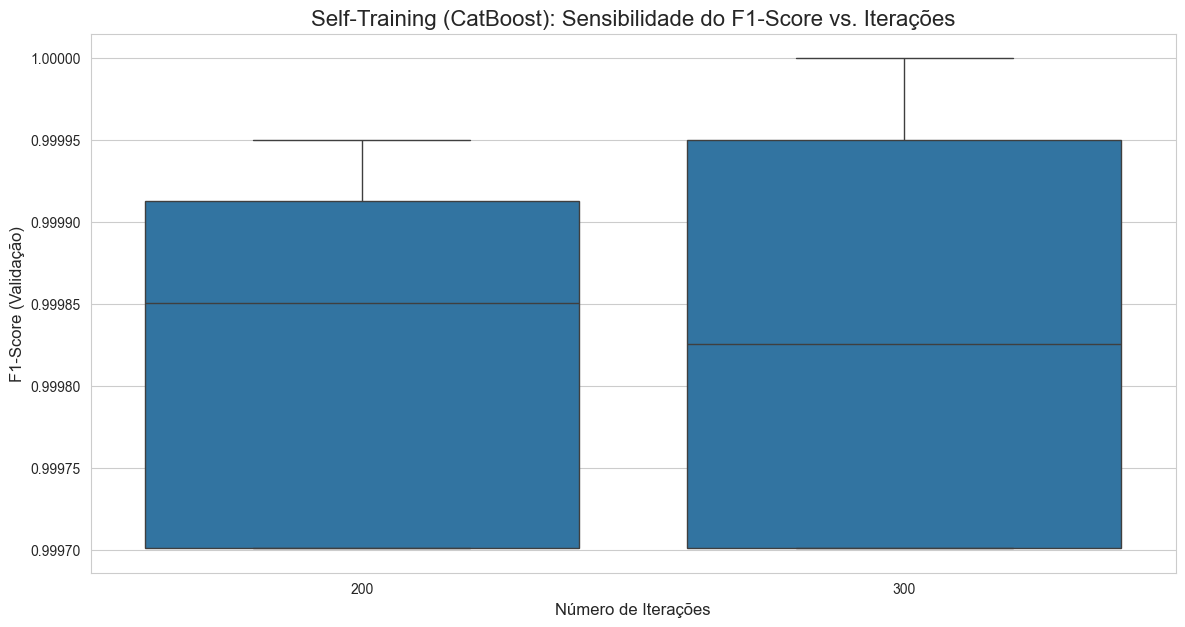

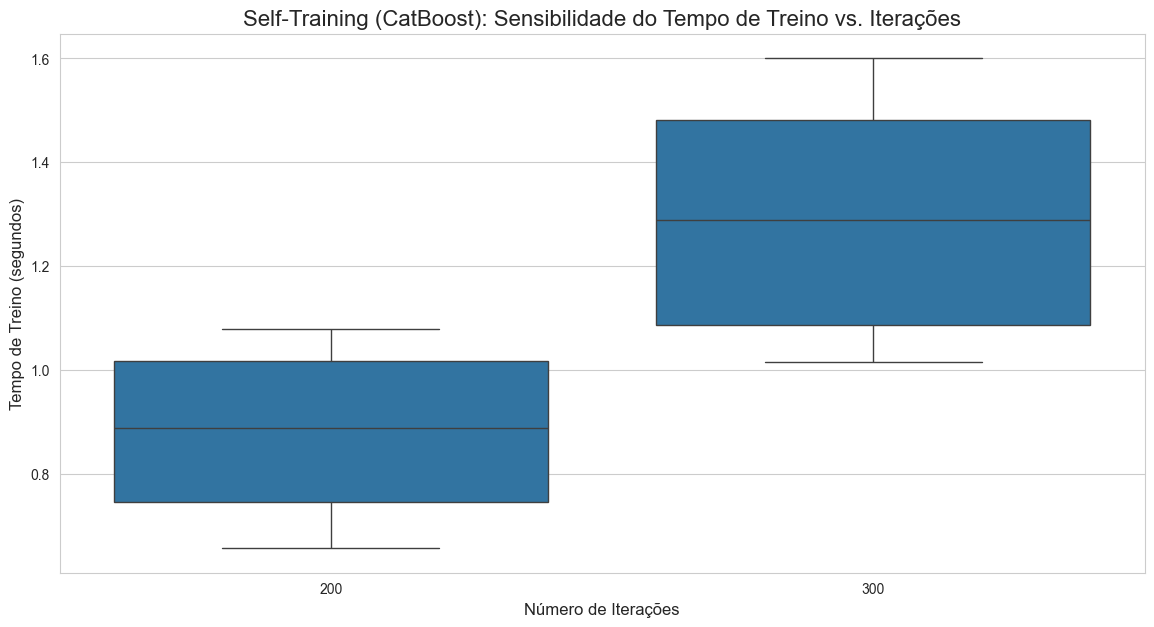

In [7]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='iterations', y='f1_score', data=results_df)
plt.title('Self-Training (CatBoost): Sensibilidade do F1-Score vs. Iterações', fontsize=16)
plt.xlabel('Número de Iterações', fontsize=12)
plt.ylabel('F1-Score (Validação)', fontsize=12)
plt.show()

plt.figure(figsize=(14, 7))
sns.boxplot(x='iterations', y='train_time', data=results_df)
plt.title('Self-Training (CatBoost): Sensibilidade do Tempo de Treino vs. Iterações', fontsize=16)
plt.xlabel('Número de Iterações', fontsize=12)
plt.ylabel('Tempo de Treino (segundos)', fontsize=12)
plt.show()

In [8]:
print("--- Otimização do Limiar de Decisão com SelfTrainingClassifier (Validation Set) ---")

# Preparar os dados de treino para o formato semi-supervisionado (-1 para não rotulados)
y_train_semi = np.copy(y_train)
unlabeled_mask = ~np.isin(np.arange(len(y_train)), labels_to_keep_indices)
y_train_semi[unlabeled_mask] = -1

print(f"Distribuição de rótulos para treino: {pd.Series(y_train_semi).value_counts().to_dict()}")

# 1. Instanciar o modelo base (expert) com os melhores hiperparâmetros
base_classifier = catboost.CatBoostClassifier(
    iterations=int(best_params['iterations']),
    depth=int(best_params['depth']),
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    random_seed=42,
    thread_count=-1,
    verbose=0
)

# 2. Envolver o modelo base com o SelfTrainingClassifier
model_for_tuning = SelfTrainingClassifier(
    base_classifier=base_classifier,
    threshold=0.95,  # Confiança mínima para criar um pseudo-rótulo
    verbose=True
)

# 3. Treinar o modelo semi-supervisionado
model_for_tuning.fit(X_train_pca, y_train_semi)

# 4. Obter probabilidades no conjunto de validação para encontrar o limiar
y_probs_val = model_for_tuning.predict_proba(X_val_pca)[:, 1]

# O resto da lógica para encontrar o melhor limiar permanece a mesma
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"\nMelhor Limiar de Decisão encontrado: {best_threshold:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.title("Self-Training (CatBoost): F1-Score vs. Limiar de Decisão")
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

--- Otimização do Limiar de Decisão com SelfTrainingClassifier (Validation Set) ---


NameError: name 'labels_to_keep_indices' is not defined

In [ ]:
print("--- Otimização do Limiar de Decisão com SelfTrainingClassifier (Validation Set) ---")

# Preparar os dados de treino para o formato semi-supervisionado (-1 para não rotulados)
y_train_semi = np.copy(y_train)
unlabeled_mask = ~np.isin(np.arange(len(y_train)), labels_to_keep_indices)
y_train_semi[unlabeled_mask] = -1

print(f"Distribuição de rótulos para treino: {pd.Series(y_train_semi).value_counts().to_dict()}")

# 1. Instanciar o modelo base (expert) com os melhores hiperparâmetros
base_classifier = catboost.CatBoostClassifier(
    iterations=int(best_params['iterations']),
    depth=int(best_params['depth']),
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    random_seed=42,
    thread_count=-1,
    verbose=0
)

# 2. Envolver o modelo base com o SelfTrainingClassifier
model_for_tuning = SelfTrainingClassifier(
    base_classifier=base_classifier,
    threshold=0.95,  # Confiança mínima para criar um pseudo-rótulo
    verbose=True
)

# 3. Treinar o modelo semi-supervisionado
model_for_tuning.fit(X_train_pca, y_train_semi)

# 4. Obter probabilidades no conjunto de validação para encontrar o limiar
y_probs_val = model_for_tuning.predict_proba(X_val_pca)[:, 1]

# O resto da lógica para encontrar o melhor limiar permanece a mesma
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"\nMelhor Limiar de Decisão encontrado: {best_threshold:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.title("Self-Training (CatBoost): F1-Score vs. Limiar de Decisão")
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

In [ ]:
# Combinar dados de treino e validação
X_train_full = sparse.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

# Preparar o conjunto final de treino semi-supervisionado (-1 para não rotulados)
y_train_full_semi = np.copy(y_train_full)
# Reutilizamos a proporção de rótulos, mas no conjunto completo
final_labels_to_keep_indices, _ = train_test_split(
    np.arange(len(y_train_full)), train_size=label_proportion, random_state=42, stratify=y_train_full
)
final_unlabeled_mask = ~np.isin(np.arange(len(y_train_full)), final_labels_to_keep_indices)
y_train_full_semi[final_unlabeled_mask] = -1

print("Distribuição final para treino:", pd.Series(y_train_full_semi).value_counts().to_dict())

# Instanciar o modelo base final com os melhores hiperparâmetros
final_base_classifier = catboost.CatBoostClassifier(
    iterations=int(best_params['iterations']),
    depth=int(best_params['depth']),
    learning_rate=best_params['learning_rate'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    random_seed=42,
    thread_count=-1,
    verbose=0
)

# Instanciar o classificador semi-supervisionado final
final_model = SelfTrainingClassifier(
    base_classifier=final_base_classifier,
    threshold=0.95,
    verbose=True
)

# Treinar o modelo final
print("\nTreinando o modelo final Self-Training (CatBoost)...")
final_model.fit(X_train_full, y_train_full_semi)
print("Treino concluído.")

# Fazer previsões no conjunto de teste
y_pred_test_probs = final_model.predict_proba(X_test_pca)[:, 1]
y_pred_test_tuned = (y_pred_test_probs >= best_threshold).astype(int)

# Avaliar o desempenho final
print("\n--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_test_tuned, target_names=['Normal', 'Anomalia']))

# Métricas no conjunto de teste
roc_auc_test = roc_auc_score(y_test, y_pred_test_probs)
print(f"\nROC AUC (Teste): {roc_auc_test:.4f}")

# Visualizar a Matriz de Confusão
print("--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---")
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Normal', 'Anomalia'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.show()